In [105]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [106]:
data_dir = Path("data")
INDIR = Path("data/data_raw")
OUTDIR = Path("data/data_processed")

OUTDIR.mkdir(parents=True, exist_ok=True)

## Tratamento de PARTICIPANTES_2024

In [107]:
arquivo = INDIR / "PARTICIPANTES_2024.csv"
df = pd.read_csv(arquivo, sep=';', encoding='latin-1')

In [108]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display(df.head())

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023
0,210062064233,2024,5,F,1,1,1,1,3,NaN,0,4314902,Porto Alegre,43,RS,F,F,C,D,4,B,C,A,C,D,C,B,B,A,B,B,B,D,A,B,B,E,A
1,210062064234,2024,11,F,1,1,1,1,10,NaN,0,4318903,São Luiz Gonzaga,43,RS,B,C,A,D,2,B,E,A,B,B,B,B,B,A,A,A,A,B,A,B,A,C,A
2,210062064235,2024,11,F,1,1,1,1,9,NaN,0,4320107,Sarandi,43,RS,H,F,F,D,5,B,J,A,C,D,B,B,C,A,B,B,B,D,B,B,A,D,A
3,210062064236,2024,3,F,1,3,1,2,0,1.0,0,4313409,Novo Hamburgo,43,RS,B,B,B,B,6,A,C,A,B,C,B,A,B,A,B,A,A,A,A,B,A,D,A
4,210062064237,2024,16,M,3,1,1,1,18,NaN,0,4309209,Gravataí,43,RS,B,B,C,C,2,A,A,A,B,C,A,A,B,A,A,A,A,B,A,B,A,B,A


In [109]:
df_participantes = df[['IN_TREINEIRO', 'SG_UF_PROVA', 'Q007', 'NO_MUNICIPIO_PROVA']]

In [110]:
df_participantes.isnull().mean()*100

IN_TREINEIRO          0.0
SG_UF_PROVA           0.0
Q007                  0.0
NO_MUNICIPIO_PROVA    0.0
dtype: float64

In [111]:
df_participantes.info()

<class 'pandas.DataFrame'>
RangeIndex: 4332944 entries, 0 to 4332943
Data columns (total 4 columns):
 #   Column              Dtype
---  ------              -----
 0   IN_TREINEIRO        int64
 1   SG_UF_PROVA         str  
 2   Q007                str  
 3   NO_MUNICIPIO_PROVA  str  
dtypes: int64(1), str(3)
memory usage: 132.2 MB


In [112]:
df_participantes = df_participantes[df_participantes['IN_TREINEIRO'] != 1]
df_participantes = df_participantes.drop(columns=['IN_TREINEIRO'])

In [113]:
cor_renda_map_sm = {
    "A": 0.0,
    "B": 1.0,
    "C": 1.5,
    "D": 2.0,
    "E": 2.5,
    "F": 3.0,
    "G": 4.0,
    "H": 5.0,
    "I": 6.0,
    "J": 7.0,
    "K": 8.0,
    "L": 9.0,
    "M": 10.0,
    "N": 12.0,
    "O": 15.0,
    "P": 20.0,
    "Q": 20.0
}

df_participantes['Q007'] = df_participantes['Q007'].map(cor_renda_map_sm)
df_participantes['Q007'] = df_participantes['Q007'].astype("Float64")
df_participantes = df_participantes.rename(columns={'Q007': 'RENDA_FAMILIAR_SM'})

In [114]:
df_participantes['NO_MUNICIPIO_PROVA'] = df_participantes['NO_MUNICIPIO_PROVA'].str.upper()

In [115]:
df_participantes.head()

,SG_UF_PROVA,RENDA_FAMILIAR_SM,NO_MUNICIPIO_PROVA
0,RS,1.5,PORTO ALEGRE
1,RS,2.5,SÃO LUIZ GONZAGA
2,RS,7.0,SARANDI
3,RS,1.5,NOVO HAMBURGO
4,RS,0.0,GRAVATAÍ


In [116]:
df_participantes.info()

<class 'pandas.DataFrame'>
Index: 3488685 entries, 0 to 4332942
Data columns (total 3 columns):
 #   Column              Dtype  
---  ------              -----  
 0   SG_UF_PROVA         str    
 1   RENDA_FAMILIAR_SM   Float64
 2   NO_MUNICIPIO_PROVA  str    
dtypes: Float64(1), str(2)
memory usage: 109.8 MB


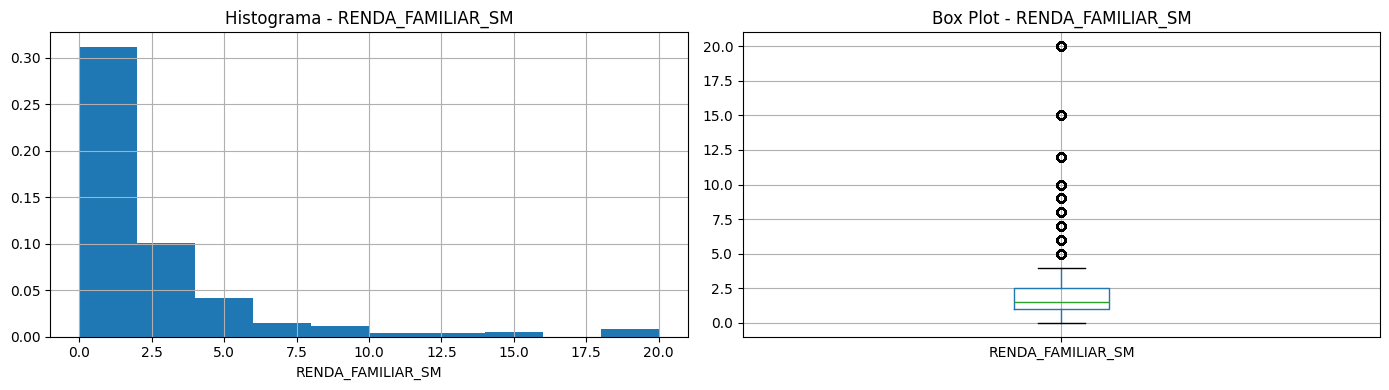

In [117]:
analise_cols = ['RENDA_FAMILIAR_SM']

for col in analise_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_participantes[col].hist(ax=ax1, density=True)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_participantes.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

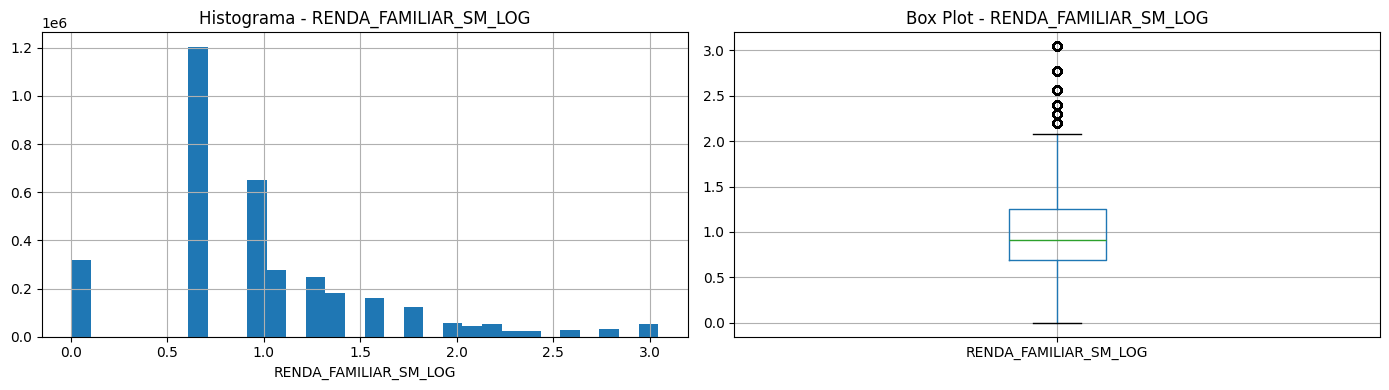

In [118]:
# TRANSFORMAÇÃO PARA ESCALA LOGARÍTMICA DE NET_SALES

df_participantes['RENDA_FAMILIAR_SM_LOG'] = np.log1p(df_participantes['RENDA_FAMILIAR_SM'])

analise_cols = ['RENDA_FAMILIAR_SM_LOG']

for col in analise_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_participantes[col].hist(ax=ax1, bins=30)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_participantes.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

In [119]:
# TRATAMENTO DE OUTLIERS

analise_de_outliers = ['RENDA_FAMILIAR_SM_LOG']
for col in analise_de_outliers:
    Q1 = df_participantes[col].quantile(0.25)
    Q3 = df_participantes[col].quantile(0.75)
    IQR = Q3 - Q1
    df_participantes = df_participantes[(df_participantes[col] >= Q1 - 1.5*IQR) & (df_participantes[col] <= Q3 + 1.5*IQR)]

print(((df_participantes.shape[0] - df_participantes.shape[0]) / df_participantes.shape[0]) * 100)
df_participantes = df_participantes.drop(columns=['RENDA_FAMILIAR_SM_LOG'])

0.0


In [120]:
df_municipio = df_participantes.groupby('NO_MUNICIPIO_PROVA').agg(
    RENDA_FAMILIAR_SM_MEDIA=('RENDA_FAMILIAR_SM', 'mean')
).reset_index()

In [121]:
df_municipio.head()

,NO_MUNICIPIO_PROVA,RENDA_FAMILIAR_SM_MEDIA
0,ABAETETUBA,1.153964
1,ABAETÉ,2.077922
2,ABREU E LIMA,1.296622
3,ACARAPE,1.005342
4,ACARAÚ,1.122531


## Tratamento Resultados

In [122]:
arquivo = INDIR / "RESULTADOS_2024.csv"
df = pd.read_csv(arquivo, sep=';', encoding='latin-1')

In [123]:
df.head()

,NU_SEQUENCIAL,NU_ANO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,206403,2024,23052929.0,2301406.0,Aratuba,23.0,CE,2.0,1.0,1.0,2301406,Aratuba,23,CE,1,1,1,1,1420.0,1383.0,1395.0,1408.0,436.8,377.8,423.4,427.1,CAABADDBBBACACACDEABDBABDDCCBACDCCBAACCABCBAC,BEABBCDABCDBAEEBDDABCCDAADDABACDDAB..........,BCADBCDCEDBDDBDDCDBCBB*BBDEAEEBCDCABBDDAAECEE,CBDCCADBBECCBADEACCBDCACECDDABBDBADBAAEDBCCAB,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,42103770.0,4218004.0,Tijucas,42.0,SC,4.0,1.0,1.0,4218004,Tijucas,42,SC,1,1,1,1,1422.0,1384.0,1396.0,1410.0,521.9,601.9,605.5,689.2,EBDEEADAECCAAEDBBEDABACDBCEEDDDEDBDDABDBCCECA,BADBACDAECEDEABBEADDBBDEBEDADEDEEACBBECABCEDA,AACEACADECBCDAEEBEDCBCBEDDCDEAEDEBDABDCECDDDB,DBAEDBECBDDBCCBBABBDECCCCEECBACCDBCDAAABBAAAD,0,BBCEDBBAEXCCAEDDBCAEDAACAAEDDDEBBECBCEEDCAACD,DADABCDCECEDEBBBEBCDBADACBCADCEBEADBAECAECEDA,AACEADDDACDADECBBDBEEBDDECCBEDDCADBBDEBCEBDCEC...,DBCECEACADABBECBEDADCCDCCABBBCECEBCEADABBADDD,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4122404,Rolândia,41,PR,1,1,1,1,1419.0,1385.0,1398.0,1407.0,363.0,548.4,557.2,456.4,CABAECDBADDCDEACABEACEABEDDCEDCDCCBDBDBDDBDCC,DAEDBCDCEBCCECADDACABDEBDCDECEDBEABECBCBBDBCD,BBCABCACDDEECCBCECECADEECCBEADBBEDBDDDEDDEECB,EBADBEDDDBCBCBCDCCECAAADDDECCDBDACACCEAEACDAC,1,BCEAACDEDCAAEDDDEBBDDBECCAEDBBAAACCAEEXCBBCED,CAEDBADBEBCCEDADBAEACBCADCEDEBBEBACECEABCDDAD,EAAACDDCDADDCBDEECEECBDCDADEEBCBEBADBCEBDBDDDD...,ABBABBADDDBBCECEADCEBCCCDBADCBEDAECADACDBCECE,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3534401,Osasco,35,SP,1,1,1,1,1421.0,1386.0,1397.0,1409.0,550.7,553.8,605.9,629.1,DDAAECECCBDBECBCBEAAADCBDDBBBEDADBDCCEEBCDAAD,ACCEADCEBDEECEDCCAADBBBCBCEABCD*AECAA........,AACEACBEDBAEEBEABDABCECDBACDCDDDCADEDDDECBEDE,BBBCDACDCABADAEACCECBCDAECECECCECBDEDABEDBCBA,0,DDBDDEBBAAEDECBCEEDCAACDBBCEDBBAEXCCAEAACCAED,ACBCADCEDBAECEDADBADBEBCDADABCDEABCAEDEBBCECE,AACEADACDDCBEDADEEBDDBDBBCEECBDCBADDDCBDEDDCEC...,CEBCEADBBCEADDDABBABBCCDCCECEDBACADECABEDADCB,1.0,140.0,200.0,160.0,160.0,80.0,740.0
4,3148322,2024,21150354.0,2100436.0,Alto Alegre do Maranhão,21.0,MA,2.0,1.0,1.0,2111508,São Mateus do Maranhão,21,MA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [124]:
df_resultado = df[['SG_UF_PROVA', 'NO_MUNICIPIO_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO' ]]

In [125]:
df.head()

,NU_SEQUENCIAL,NU_ANO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,206403,2024,23052929.0,2301406.0,Aratuba,23.0,CE,2.0,1.0,1.0,2301406,Aratuba,23,CE,1,1,1,1,1420.0,1383.0,1395.0,1408.0,436.8,377.8,423.4,427.1,CAABADDBBBACACACDEABDBABDDCCBACDCCBAACCABCBAC,BEABBCDABCDBAEEBDDABCCDAADDABACDDAB..........,BCADBCDCEDBDDBDDCDBCBB*BBDEAEEBCDCABBDDAAECEE,CBDCCADBBECCBADEACCBDCACECDDABBDBADBAAEDBCCAB,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,42103770.0,4218004.0,Tijucas,42.0,SC,4.0,1.0,1.0,4218004,Tijucas,42,SC,1,1,1,1,1422.0,1384.0,1396.0,1410.0,521.9,601.9,605.5,689.2,EBDEEADAECCAAEDBBEDABACDBCEEDDDEDBDDABDBCCECA,BADBACDAECEDEABBEADDBBDEBEDADEDEEACBBECABCEDA,AACEACADECBCDAEEBEDCBCBEDDCDEAEDEBDABDCECDDDB,DBAEDBECBDDBCCBBABBDECCCCEECBACCDBCDAAABBAAAD,0,BBCEDBBAEXCCAEDDBCAEDAACAAEDDDEBBECBCEEDCAACD,DADABCDCECEDEBBBEBCDBADACBCADCEBEADBAECAECEDA,AACEADDDACDADECBBDBEEBDDECCBEDDCADBBDEBCEBDCEC...,DBCECEACADABBECBEDADCCDCCABBBCECEBCEADABBADDD,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4122404,Rolândia,41,PR,1,1,1,1,1419.0,1385.0,1398.0,1407.0,363.0,548.4,557.2,456.4,CABAECDBADDCDEACABEACEABEDDCEDCDCCBDBDBDDBDCC,DAEDBCDCEBCCECADDACABDEBDCDECEDBEABECBCBBDBCD,BBCABCACDDEECCBCECECADEECCBEADBBEDBDDDEDDEECB,EBADBEDDDBCBCBCDCCECAAADDDECCDBDACACCEAEACDAC,1,BCEAACDEDCAAEDDDEBBDDBECCAEDBBAAACCAEEXCBBCED,CAEDBADBEBCCEDADBAEACBCADCEDEBBEBACECEABCDDAD,EAAACDDCDADDCBDEECEECBDCDADEEBCBEBADBCEBDBDDDD...,ABBABBADDDBBCECEADCEBCCCDBADCBEDAECADACDBCECE,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3534401,Osasco,35,SP,1,1,1,1,1421.0,1386.0,1397.0,1409.0,550.7,553.8,605.9,629.1,DDAAECECCBDBECBCBEAAADCBDDBBBEDADBDCCEEBCDAAD,ACCEADCEBDEECEDCCAADBBBCBCEABCD*AECAA........,AACEACBEDBAEEBEABDABCECDBACDCDDDCADEDDDECBEDE,BBBCDACDCABADAEACCECBCDAECECECCECBDEDABEDBCBA,0,DDBDDEBBAAEDECBCEEDCAACDBBCEDBBAEXCCAEAACCAED,ACBCADCEDBAECEDADBADBEBCDADABCDEABCAEDEBBCECE,AACEADACDDCBEDADEEBDDBDBBCEECBDCBADDDCBDEDDCEC...,CEBCEADBBCEADDDABBABBCCDCCECEDBACADECABEDADCB,1.0,140.0,200.0,160.0,160.0,80.0,740.0
4,3148322,2024,21150354.0,2100436.0,Alto Alegre do Maranhão,21.0,MA,2.0,1.0,1.0,2111508,São Mateus do Maranhão,21,MA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [126]:
df_resultado.isnull().mean()*100

SG_UF_PROVA            0.000000
NO_MUNICIPIO_PROVA     0.000000
TP_PRESENCA_CN         0.000000
TP_PRESENCA_CH         0.000000
TP_PRESENCA_LC         0.000000
TP_PRESENCA_MT         0.000000
NU_NOTA_CN            30.648054
NU_NOTA_CH            26.886777
NU_NOTA_LC            26.886777
NU_NOTA_MT            30.648054
NU_NOTA_REDACAO       26.886777
dtype: float64

In [127]:
df_resultado = df_resultado[df_resultado['TP_PRESENCA_CN'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_CH'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_LC'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_MT'] == 1]

df_resultado = df_resultado.drop(columns=['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT'])

In [128]:
df_resultado['NO_MUNICIPIO_PROVA'] = df_resultado['NO_MUNICIPIO_PROVA'].str.upper()

In [129]:
df_resultado.head()

,SG_UF_PROVA,NO_MUNICIPIO_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,CE,ARATUBA,436.8,377.8,423.4,427.1,300.0
1,SC,TIJUCAS,521.9,601.9,605.5,689.2,920.0
2,PR,ROLÂNDIA,363.0,548.4,557.2,456.4,480.0
3,SP,OSASCO,550.7,553.8,605.9,629.1,740.0
7,RN,NATAL,482.7,531.6,439.2,496.7,360.0


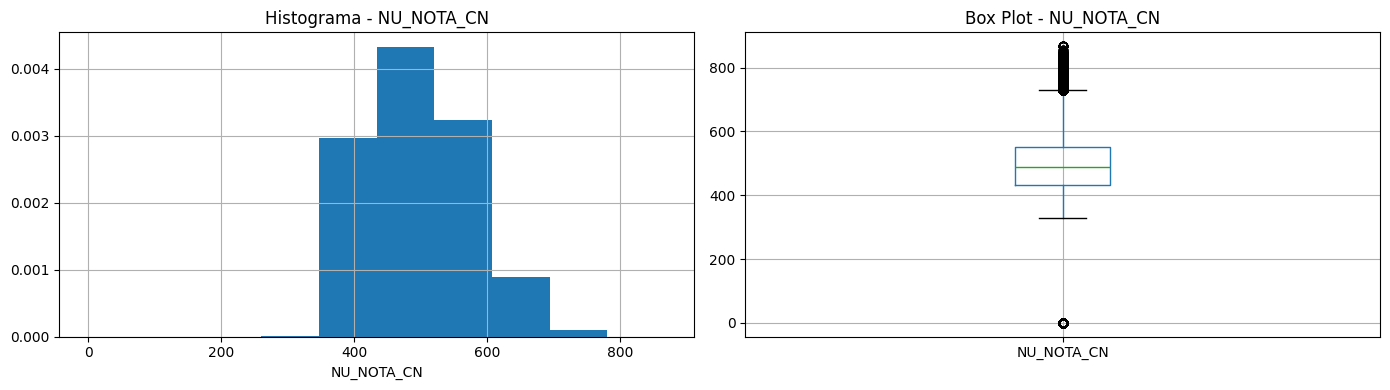

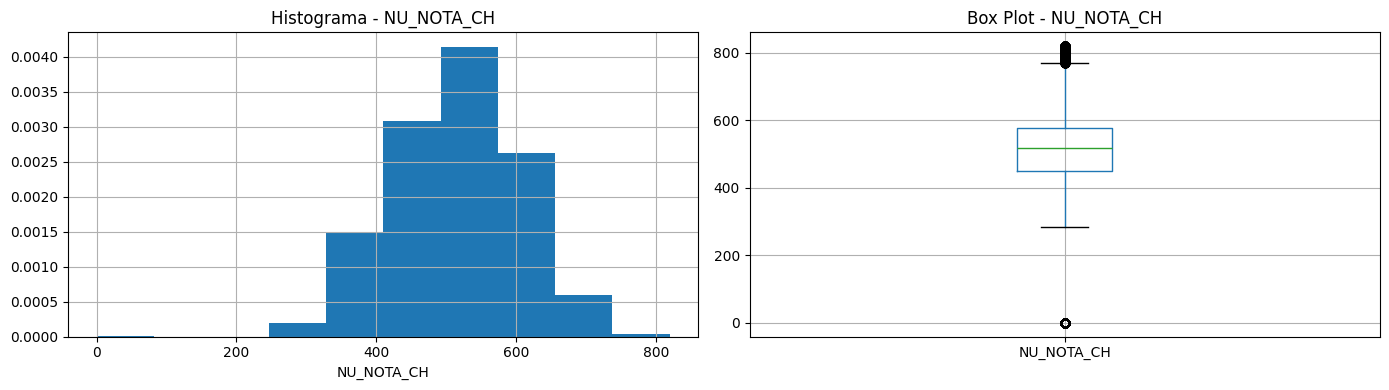

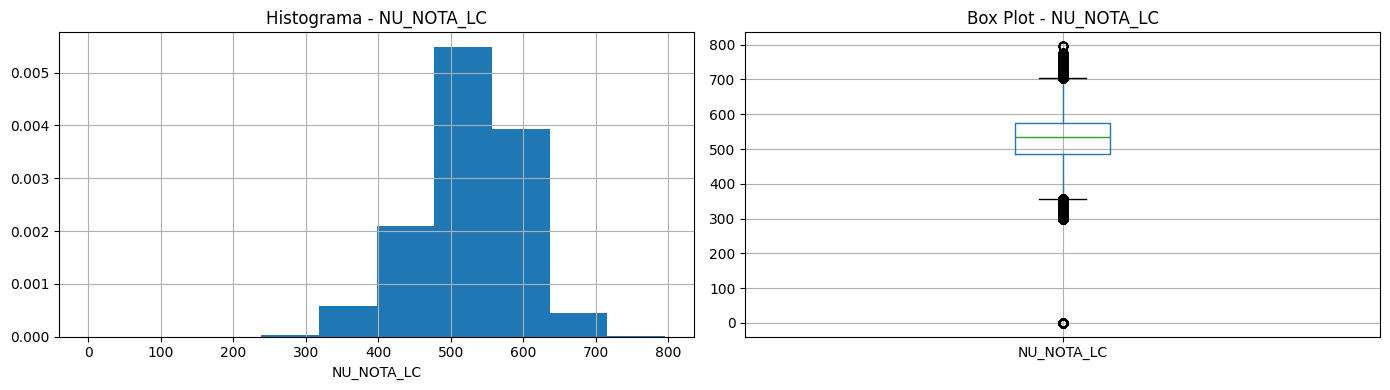

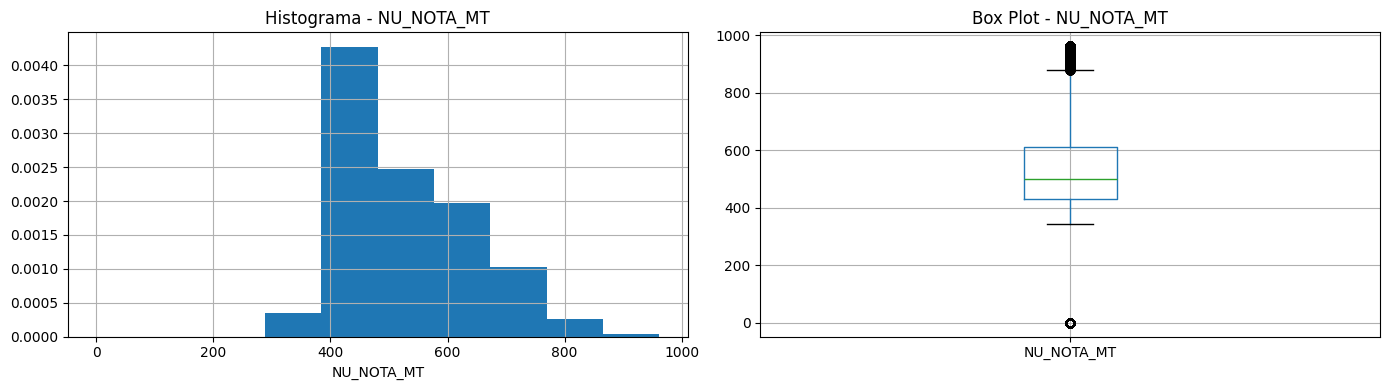

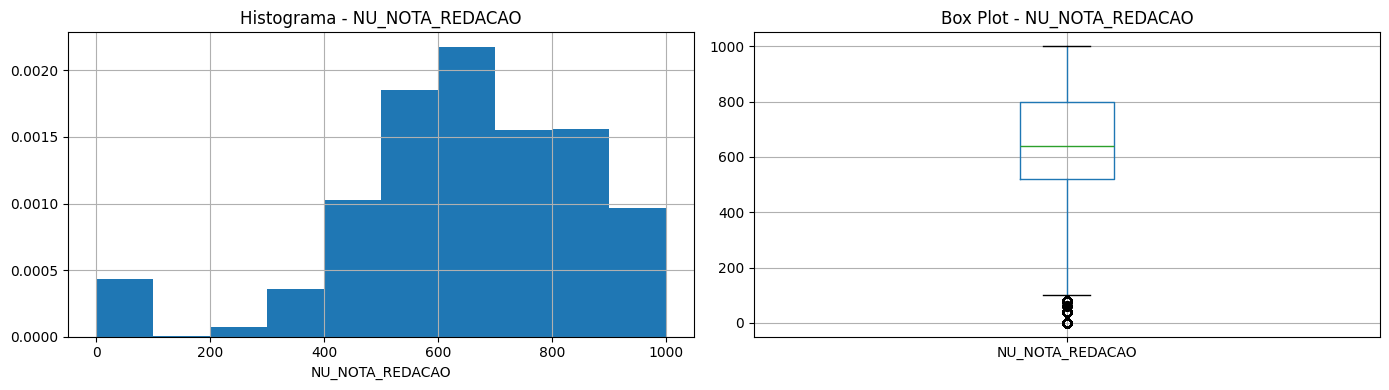

In [130]:
analise_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

for col in analise_notas:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_resultado[col].hist(ax=ax1, density=True)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_resultado.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

In [131]:
for col in analise_notas:
    Q1 = df_resultado[col].quantile(0.25)
    Q3 = df_resultado[col].quantile(0.75)
    IQR = Q3 - Q1
    df_resultado = df_resultado[(df_resultado[col] >= Q1 - 1.5*IQR) & (df_resultado[col] <= Q3 + 1.5*IQR)]

print(((df_resultado.shape[0] - df_resultado.shape[0]) / df_resultado.shape[0]) * 100)

0.0


In [132]:
df_resultado.head()

,SG_UF_PROVA,NO_MUNICIPIO_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
0,CE,ARATUBA,436.8,377.8,423.4,427.1,300.0
1,SC,TIJUCAS,521.9,601.9,605.5,689.2,920.0
2,PR,ROLÂNDIA,363.0,548.4,557.2,456.4,480.0
3,SP,OSASCO,550.7,553.8,605.9,629.1,740.0
7,RN,NATAL,482.7,531.6,439.2,496.7,360.0


In [133]:
df_resultado = df_resultado.groupby('NO_MUNICIPIO_PROVA').agg(
    UF=('SG_UF_PROVA', 'first'),
    QTD_PARTICIPANTES=('NO_MUNICIPIO_PROVA', 'size'),
    NU_NOTA_CN_MEDIA=('NU_NOTA_CN', 'mean'),
    NU_NOTA_CH_MEDIA=('NU_NOTA_CH', 'mean'),
    NU_NOTA_LC_MEDIA=('NU_NOTA_LC', 'mean'),
    NU_NOTA_MT_MEDIA=('NU_NOTA_MT', 'mean'),
    NU_NOTA_REDACAO_MEDIA=('NU_NOTA_REDACAO', 'mean')
).reset_index()

In [134]:
df_clustering = df_resultado.merge(
    df_municipio,
    on='NO_MUNICIPIO_PROVA',
    how='left'
)

In [135]:
df_clustering.isnull().sum()

NO_MUNICIPIO_PROVA         0
UF                         0
QTD_PARTICIPANTES          0
NU_NOTA_CN_MEDIA           0
NU_NOTA_CH_MEDIA           0
NU_NOTA_LC_MEDIA           0
NU_NOTA_MT_MEDIA           0
NU_NOTA_REDACAO_MEDIA      0
RENDA_FAMILIAR_SM_MEDIA    0
dtype: int64

In [136]:
df_clustering.head()

,NO_MUNICIPIO_PROVA,UF,QTD_PARTICIPANTES,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA,RENDA_FAMILIAR_SM_MEDIA
0,ABAETETUBA,PA,4380,464.503151,473.275868,492.725731,476.596621,636.082192,1.153964
1,ABAETÉ,MG,529,492.048204,523.686200,539.515501,547.043478,680.982987,2.077922
2,ABREU E LIMA,PE,1687,475.696799,499.807232,518.264790,497.287730,625.714286,1.296622
3,ACARAPE,CE,374,467.339037,487.118449,507.952406,506.521390,671.497326,1.005342
4,ACARAÚ,CE,1013,478.360711,489.732379,510.916486,530.821718,757.255676,1.122531


In [137]:
X_scaled = df_clustering.copy()

X_scaled = X_scaled.drop(columns=['NO_MUNICIPIO_PROVA', 'RENDA_FAMILIAR_SM_MEDIA', 'UF', 'QTD_PARTICIPANTES'])

col_scatter = ['NU_NOTA_CN_MEDIA', 'NU_NOTA_CH_MEDIA', 'NU_NOTA_LC_MEDIA', 'NU_NOTA_MT_MEDIA', 'NU_NOTA_REDACAO_MEDIA']
scaler = StandardScaler()
X_scaled[col_scatter] = scaler.fit_transform(X_scaled[col_scatter])


In [138]:
X_scaled.head()

,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA
0,-0.767010,-1.047345,-1.199740,-1.036194,-0.259157
1,0.446097,0.790820,0.941715,1.062726,0.887811
2,-0.274033,-0.079904,-0.030879,-0.419715,-0.523999
3,-0.642115,-0.542588,-0.502852,-0.144604,0.645504
4,-0.156712,-0.447274,-0.367193,0.579409,2.836157


In [139]:
caminho_tratado = OUTDIR / "ANALISE_NOTAS_ENEM_MUNICIPIOS_BRASIL_TRATADO.csv"
df_clustering.to_csv(caminho_tratado, index=False)

caminho_modelo = OUTDIR / "ANALISE_NOTAS_ENEM_MUNICIPIOS_BRASIL_MODELO.csv"
X_scaled.to_csv(caminho_modelo, index=False)